In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir(os.path.pardir)

In [ ]:
import yaml
import matplotlib.pyplot as plt

from src.orchestrator import BacktestOrchestrator
from src.analytics import BacktestAnalyser, FlatPerTrade, render_tearsheet

In [3]:
# Allows asyncio to be run in jup notebook

import nest_asyncio
nest_asyncio.apply()

In [4]:
config = yaml.safe_load(open("config/backtest_rsi.yaml"))
orchestrator = BacktestOrchestrator(config)
trade_log = orchestrator.run()

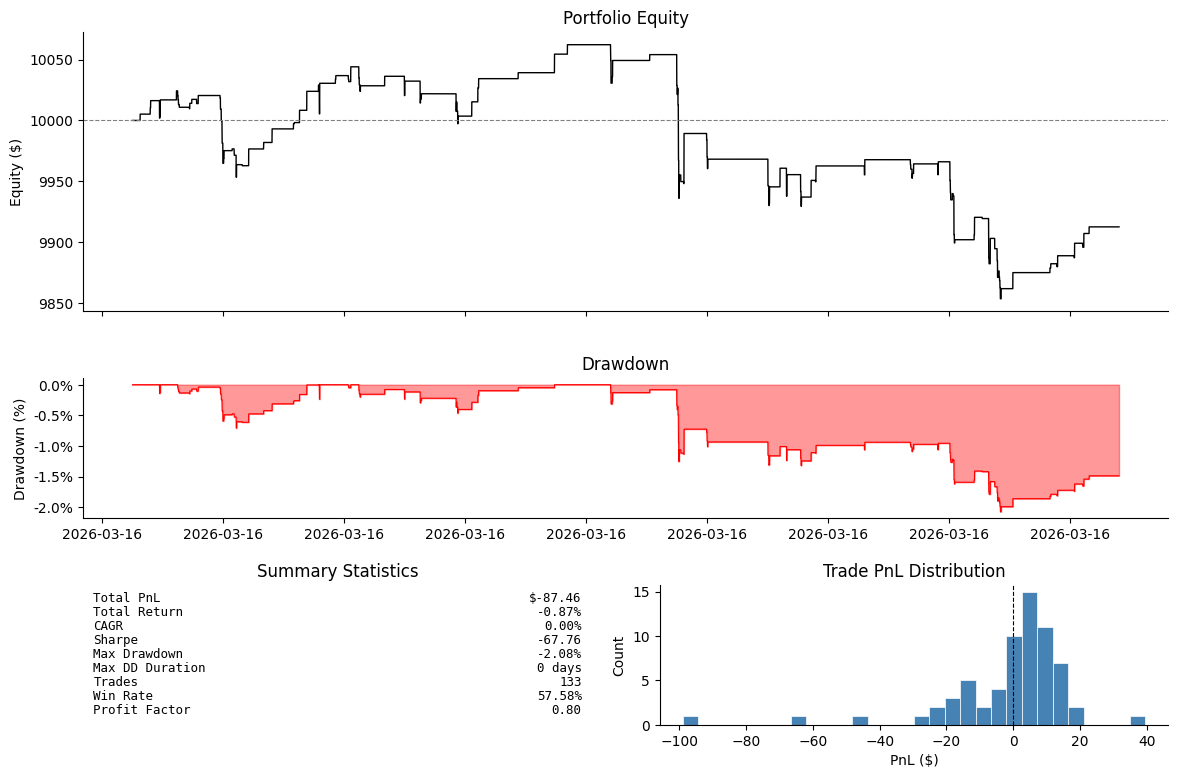

In [5]:
backtest = BacktestAnalyser(
    trade_log = trade_log,
    market_history = orchestrator.market_history,
    initial_capital = 10000,
    cost_model = FlatPerTrade(cost = 0)
)

results = backtest.run()

fig = render_tearsheet(result=results)
fig.savefig("data/processed/random_backtest_tearsheet.pdf")
plt.show()